# Part 1: Low-Rank Approximation 개념 및 Baseline 학습

## 이 노트북에서 다루는 내용
1. Low-Rank Approximation의 핵심 개념
2. CIFAR-10 데이터셋 로드
3. CNN 모델 학습 (Baseline)
4. 레이어별 특이값(Singular Value) 분석
5. Rank vs 복원 오차 곡선

## Low-Rank Approximation 핵심 개념

### SVD (Singular Value Decomposition)

행렬 $W \in \mathbb{R}^{m \times n}$에 대해:

$$W = U \Sigma V^T$$

- $U$: $(m \times m)$ 좌특이벡터 행렬
- $\Sigma$: $(m \times n)$ 특이값 대각행렬, $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $V$: $(n \times n)$ 우특이벡터 행렬

### Rank-r 근사

$$W_r = U_r \Sigma_r V_r^T$$

상위 $r$개 특이값만 사용 → **Eckart-Young 정리**: Frobenius norm에서 최적의 rank-r 근사

### 파라미터 절감

| | 원본 | 분해 후 | 조건 |
|---|---|---|---|
| Linear | $m \times n$ | $r \times (m + n)$ | $r < \frac{mn}{m+n}$ |
| Conv2d | $C_{out} \times C_{in} \times k^2$ | $C_{in} \times r + r \times C_{out} \times k^2$ | rank로 채널 축소 |

### 참고 논문
- Denton et al., 2014 - Exploiting Linear Structure Within CNNs
- Jaderberg et al., 2014 - Speeding up CNNs with Low Rank Expansions

## [1] 환경 설정 및 데이터 로드

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN, get_reconstruction_error

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10
SEED = 42
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

100%|██████████| 170M/170M [00:14<00:00, 11.9MB/s] 


학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습 및 평가 함수 정의

In [3]:
def train(model, train_loader, epochs, learning_rate, device):
    """Cross-Entropy 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def test(model, test_loader, device):
    """모델 평가"""
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


def count_parameters(model):
    """모델의 총 파라미터 수 계산"""
    return sum(p.numel() for p in model.parameters())

## [3] CNN 모델 학습 (Baseline)

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params = count_parameters(model)
print(f"CNN 모델 파라미터 수: {total_params:,}")
print(f"\n모델 구조:")
print(model)

CNN 모델 파라미터 수: 1,186,986

모델 구조:
CNN(
  (features): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [5]:
# 학습
train_losses = train(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(model, test_loader, DEVICE)

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347
Test Accuracy: 75.01%


## [4] 레이어별 파라미터 분석 (Low-Rank 관점)

In [6]:
print(f"{'Layer':<25} {'Shape':<25} {'Params':<12} {'비율':<8}")
print("-" * 70)

for name, param in model.named_parameters():
    if 'weight' in name:
        num_params = param.numel()
        ratio = num_params / total_params * 100
        print(f"{name:<25} {str(list(param.shape)):<25} {num_params:>10,} {ratio:>6.1f}%")

print("-" * 70)
print(f"{'Total':<25} {'':<25} {total_params:>10,} {'100.0%':>8}")
print(f"\n→ classifier.0.weight (2048×512)이 전체의 88.4%를 차지")
print(f"→ Low-Rank 분해의 핵심 타겟!")

Layer                     Shape                     Params       비율      
----------------------------------------------------------------------
features.0.weight         [128, 3, 3, 3]                 3,456    0.3%
features.2.weight         [64, 128, 3, 3]               73,728    6.2%
features.5.weight         [64, 64, 3, 3]                36,864    3.1%
features.7.weight         [32, 64, 3, 3]                18,432    1.6%
classifier.0.weight       [512, 2048]                1,048,576   88.3%
classifier.3.weight       [10, 512]                      5,120    0.4%
----------------------------------------------------------------------
Total                                                1,186,986   100.0%

→ classifier.0.weight (2048×512)이 전체의 88.4%를 차지
→ Low-Rank 분해의 핵심 타겟!


## [5] 특이값(Singular Value) 분석

특이값이 빠르게 감소하는 레이어 = low-rank 분해에 적합

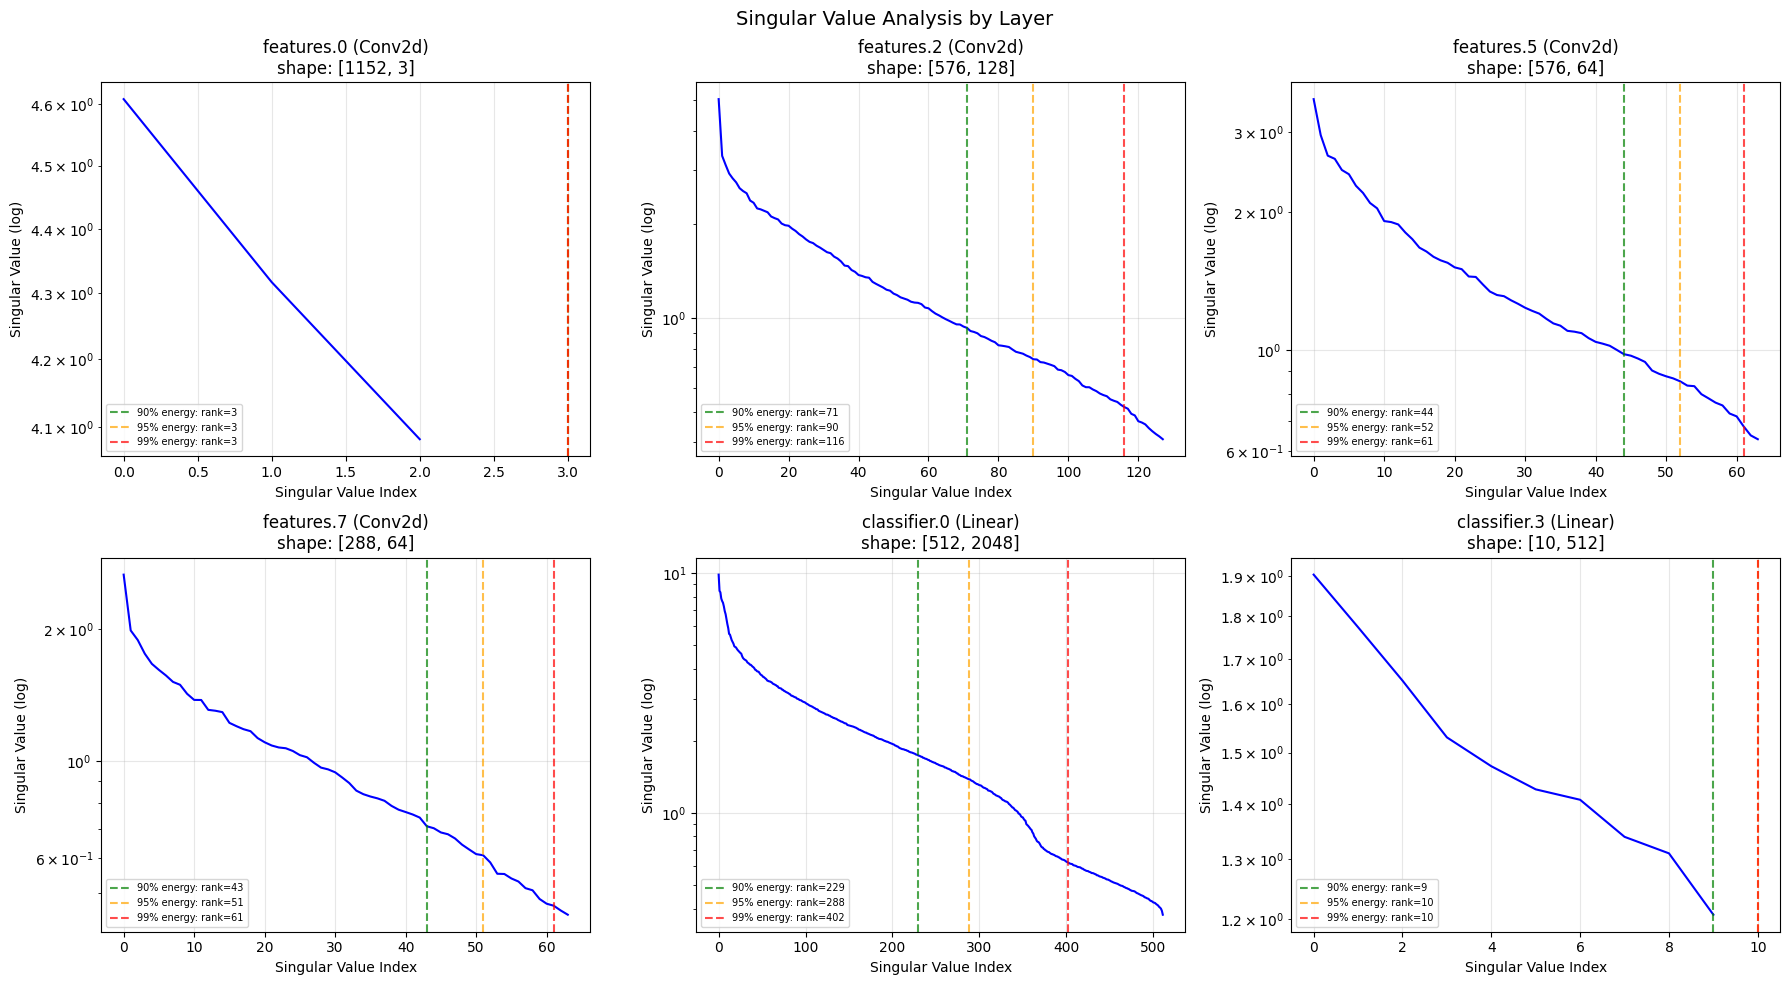

In [ ]:
# 레이어별 특이값 분포 시각화
model_cpu = model.cpu()

layers_to_analyze = []
for name, module in model_cpu.named_modules():
    if isinstance(module, nn.Linear):
        W = module.weight.data
        layers_to_analyze.append((name, W, 'Linear'))
    elif isinstance(module, nn.Conv2d):
        W = module.weight.data
        out_c, in_c, k_h, k_w = W.shape
        W_reshaped = W.reshape(out_c * k_h * k_w, in_c)
        layers_to_analyze.append((name, W_reshaped, 'Conv2d'))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Singular Value Analysis by Layer', fontsize=14)

for idx, (name, W, layer_type) in enumerate(layers_to_analyze):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]

    _, S, _ = torch.linalg.svd(W, full_matrices=False)
    S = S.numpy()

    ax.semilogy(S, 'b-', linewidth=1.5)
    ax.set_title(f'{name} ({layer_type})\nshape: {list(W.shape)}')
    ax.set_xlabel('Singular Value Index')
    ax.set_ylabel('Singular Value (log)')
    ax.grid(True, alpha=0.3)

    energy = np.cumsum(S ** 2) / np.sum(S ** 2)
    for threshold, color in [(0.90, 'green'), (0.95, 'orange'), (0.99, 'red')]:
        rank_at = np.searchsorted(energy, threshold) + 1
        ax.axvline(x=rank_at, color=color, linestyle='--', alpha=0.7,
                   label=f'{threshold*100:.0f}% energy: rank={rank_at}')

    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## [6] 누적 에너지 곡선

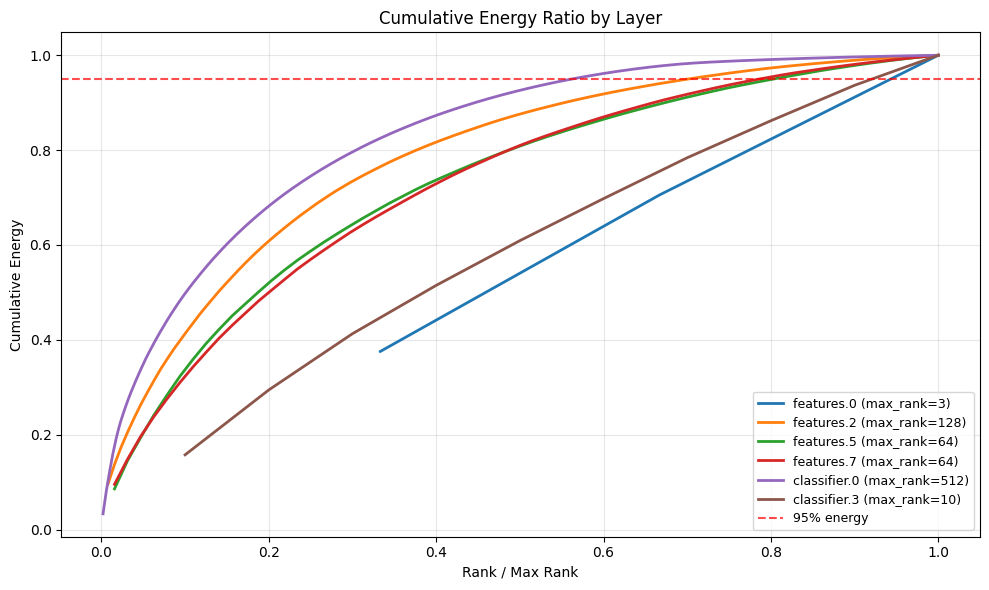

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for name, module in model_cpu.named_modules():
    if isinstance(module, nn.Linear):
        W = module.weight.data
    elif isinstance(module, nn.Conv2d):
        W = module.weight.data
        out_c, in_c, k_h, k_w = W.shape
        W = W.reshape(out_c * k_h * k_w, in_c)
    else:
        continue

    _, S, _ = torch.linalg.svd(W, full_matrices=False)
    S = S.numpy()
    energy = np.cumsum(S ** 2) / np.sum(S ** 2)
    ranks_normalized = np.arange(1, len(S) + 1) / len(S)

    ax.plot(ranks_normalized, energy, linewidth=2,
            label=f'{name} (max_rank={len(S)})')

ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% energy')
ax.set_xlabel('Rank / Max Rank')
ax.set_ylabel('Cumulative Energy')
ax.set_title('Cumulative Energy Ratio by Layer')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## [7] Rank vs 복원 오차 곡선

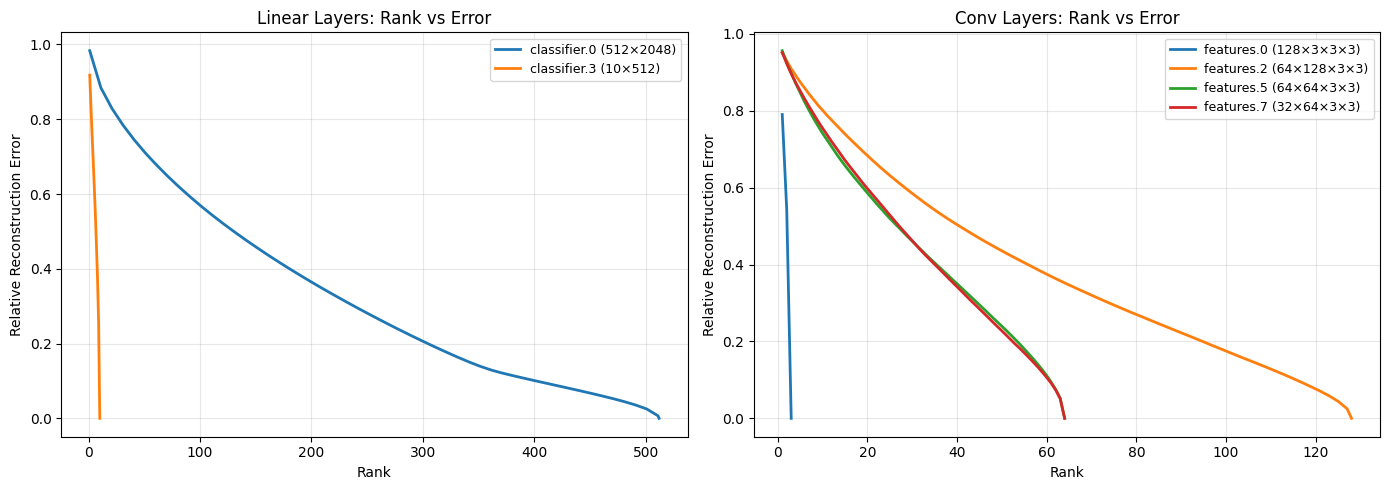

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear 레이어
ax1 = axes[0]
for name, module in model_cpu.named_modules():
    if isinstance(module, nn.Linear):
        W = module.weight.data
        max_rank = min(W.shape)
        ranks = list(range(1, max_rank + 1, max(1, max_rank // 50)))
        if max_rank not in ranks:
            ranks.append(max_rank)
        errors = [get_reconstruction_error(W, r) for r in ranks]
        ax1.plot(ranks, errors, linewidth=2, label=f'{name} ({W.shape[0]}×{W.shape[1]})')

ax1.set_xlabel('Rank')
ax1.set_ylabel('Relative Reconstruction Error')
ax1.set_title('Linear Layers: Rank vs Error')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Conv 레이어
ax2 = axes[1]
for name, module in model_cpu.named_modules():
    if isinstance(module, nn.Conv2d):
        W = module.weight.data
        out_c, in_c, k_h, k_w = W.shape
        W_reshaped = W.reshape(out_c * k_h * k_w, in_c)
        max_rank = min(W_reshaped.shape)
        ranks = list(range(1, max_rank + 1, max(1, max_rank // 50)))
        if max_rank not in ranks:
            ranks.append(max_rank)
        errors = [get_reconstruction_error(W_reshaped, r) for r in ranks]
        ax2.plot(ranks, errors, linewidth=2,
                 label=f'{name} ({out_c}×{in_c}×{k_h}×{k_w})')

ax2.set_xlabel('Rank')
ax2.set_ylabel('Relative Reconstruction Error')
ax2.set_title('Conv Layers: Rank vs Error')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## [8] 에너지 기반 Rank 분석

In [10]:
print(f"{'Layer':<25} {'Shape':<20} {'95% Rank':<10} {'99% Rank':<10} {'Max Rank':<10}")
print("-" * 75)

for name, module in model_cpu.named_modules():
    if isinstance(module, nn.Linear):
        W = module.weight.data
        _, S, _ = torch.linalg.svd(W, full_matrices=False)
        energy = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2)
        rank_95 = (energy < 0.95).sum().item() + 1
        rank_99 = (energy < 0.99).sum().item() + 1
        max_rank = len(S)
        print(f"{name + '.weight':<25} {str(list(W.shape)):<20} {rank_95:<10} {rank_99:<10} {max_rank:<10}")
    elif isinstance(module, nn.Conv2d):
        W = module.weight.data
        out_c, in_c, k_h, k_w = W.shape
        W_reshaped = W.reshape(out_c * k_h * k_w, in_c)
        _, S, _ = torch.linalg.svd(W_reshaped, full_matrices=False)
        energy = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2)
        rank_95 = (energy < 0.95).sum().item() + 1
        rank_99 = (energy < 0.99).sum().item() + 1
        max_rank = len(S)
        print(f"{name + '.weight':<25} {str(list(W.shape)):<20} {rank_95:<10} {rank_99:<10} {max_rank:<10}")

Layer                     Shape                95% Rank   99% Rank   Max Rank  
---------------------------------------------------------------------------
features.0.weight         [128, 3, 3, 3]       3          3          3         
features.2.weight         [64, 128, 3, 3]      90         116        128       
features.5.weight         [64, 64, 3, 3]       52         61         64        
features.7.weight         [32, 64, 3, 3]       51         61         64        
classifier.0.weight       [512, 2048]          288        402        512       
classifier.3.weight       [10, 512]            10         10         10        


## 결과 요약

In [11]:
print("=" * 60)
print("결과 요약")
print("=" * 60)
print(f"모델: CNN ({total_params:,} parameters)")
print(f"Baseline 정확도: {baseline_accuracy:.2f}%")
print(f"\n핵심 관찰:")
print(f"  - classifier.0 (Linear 2048→512)이 파라미터의 88.4%")
print(f"  - SVD로 이 레이어를 분해하면 큰 압축 효과")
print(f"  - 특이값 감소 패턴으로 적절한 rank를 선택 가능")
print(f"\n다음 단계:")
print(f"  - Part 2: Linear 레이어 SVD 분해")
print(f"  - Part 3: Conv 레이어 채널 분해")
print(f"  - Part 4: 종합 실험 분석")

결과 요약
모델: CNN (1,186,986 parameters)
Baseline 정확도: 75.01%

핵심 관찰:
  - classifier.0 (Linear 2048→512)이 파라미터의 88.4%
  - SVD로 이 레이어를 분해하면 큰 압축 효과
  - 특이값 감소 패턴으로 적절한 rank를 선택 가능

다음 단계:
  - Part 2: Linear 레이어 SVD 분해
  - Part 3: Conv 레이어 채널 분해
  - Part 4: 종합 실험 분석
